#**Limpieza de Datos**

##**Afluencia por estaciones del Metro, CDMX - 2026**
Fuente: Portal de Datos Abiertos. Afluencia Diaria del Metro (Desglosada). *[datos.cdmx.gob.mx](https://datos.cdmx.gob.mx/dataset/afluencia-diaria-del-metro-cdmx/resource/cce544e1-dc6b-42b4-bc27-0d8e6eb3ed72)*

In [50]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [145]:
df = pd.read_csv('/content/Afluencia estaciones metro cdmx.csv')

df.sample(5)

,fecha,mes,anio,linea,estacion,tipo_pago,afluencia,temporal_fecha,..anio_fecha
18989,2026-02-02,Febrero,2026,Linea 6,TezozÃ³moc,Gratuidad,368,2026-02,2026
25243,2026-02-13,Febrero,2026,Linea 2,Hidalgo,Prepago,24249,2026-02,2026
18526,2026-02-01,Febrero,2026,Linea 8,UAM-I,Prepago,9101,2026-02,2026
9747,2026-01-17,Enero,2026,Linea 8,Cerro de la Estrella,Boleto,0,2026-01,2026
26200,2026-02-14,Febrero,2026,Linea A,La Paz,Prepago,31804,2026-02,2026


In [144]:
print(df.shape)

(34515, 9)


In [52]:
df['afluencia'].isna().sum()

np.int64(0)

In [53]:
#Se identifican caracteres que se deben de reemplazar

df['estacion'].unique()

array(['PantitlÃ¡n', 'Zaragoza', 'GÃ³mez Farias',
       'Boulevard Puerto AÃ©reo', 'Balbuena', 'Moctezuma', 'San LÃ¡zaro',
       'Candelaria', 'Merced', 'Pino SuÃ¡rez', 'Isabel la CatÃ³lica',
       'Salto del Agua', 'Balderas', 'CuauhtÃ©moc', 'Insurgentes',
       'Sevilla', 'Chapultepec', 'JuanacatlÃ¡n', 'Tacubaya',
       'Observatorio', 'Cuatro Caminos', 'Panteones', 'Tacuba',
       'CuitlÃ¡huac', 'Popotla', 'Colegio Militar', 'Normal', 'San Cosme',
       'RevoluciÃ³n', 'Hidalgo', 'Bellas Artes', 'Allende',
       'ZÃ³calo/Tenochtitlan', 'San Antonio Abad', 'Chabacano',
       'Viaducto', 'Xola', 'Villa de Cortés', 'Nativitas', 'Portales',
       'Ermita', 'General Anaya', 'TasqueÃ±a', 'Indios Verdes',
       'Deportivo 18 de Marzo', 'Potrero', 'La Raza', 'Tlatelolco',
       'Guerrero', 'JuÃ¡rez', 'NiÃ±os HÃ©roes', 'Hospital General',
       'Centro MÃ©dico', 'EtiopÃ\xada/Plaza de la Transparencia',
       'Eugenia', 'DivisiÃ³n del Norte', 'Zapata', 'CoyoacÃ¡n',
       'Vivero

In [54]:
#El DF original se duplica para hacer la transformación de datos

data = df.copy()

In [55]:
#Los caracteres pueden reemplazarse con el método .replace

data['estacion'] = data['estacion'].str.replace('Ã¡','á').str.replace('Ã©','é').str.replace('Ã\xad','í').str.replace('Ã³','ó').str.replace('Ãº','ú').str.replace('Ã±','ñ').str.replace('Ã\x81','Á')


In [56]:
#La columna con nombres de estaciones fue modificada

data['estacion'].unique()

array(['Pantitlán', 'Zaragoza', 'Gómez Farias', 'Boulevard Puerto Aéreo',
       'Balbuena', 'Moctezuma', 'San Lázaro', 'Candelaria', 'Merced',
       'Pino Suárez', 'Isabel la Católica', 'Salto del Agua', 'Balderas',
       'Cuauhtémoc', 'Insurgentes', 'Sevilla', 'Chapultepec',
       'Juanacatlán', 'Tacubaya', 'Observatorio', 'Cuatro Caminos',
       'Panteones', 'Tacuba', 'Cuitláhuac', 'Popotla', 'Colegio Militar',
       'Normal', 'San Cosme', 'Revolución', 'Hidalgo', 'Bellas Artes',
       'Allende', 'Zócalo/Tenochtitlan', 'San Antonio Abad', 'Chabacano',
       'Viaducto', 'Xola', 'Villa de Cortés', 'Nativitas', 'Portales',
       'Ermita', 'General Anaya', 'Tasqueña', 'Indios Verdes',
       'Deportivo 18 de Marzo', 'Potrero', 'La Raza', 'Tlatelolco',
       'Guerrero', 'Juárez', 'Niños Héroes', 'Hospital General',
       'Centro Médico', 'Etiopía/Plaza de la Transparencia', 'Eugenia',
       'División del Norte', 'Zapata', 'Coyoacán',
       'Viveros/Derechos Humanos', 'Miguel 

In [57]:
#Solo se utilizarán los datos del mes de febrero

data_febrero = data[data['mes'] == 'Febrero'].copy()
data_febrero.head()

,fecha,mes,anio,linea,estacion,tipo_pago,afluencia,temporal_fecha,..anio_fecha
18135,2026-02-01,Febrero,2026,Linea 1,Pantitlán,Boleto,0,2026-02,2026
18136,2026-02-01,Febrero,2026,Linea 1,Pantitlán,Prepago,16877,2026-02,2026
18137,2026-02-01,Febrero,2026,Linea 1,Pantitlán,Gratuidad,2698,2026-02,2026
18138,2026-02-01,Febrero,2026,Linea 1,Zaragoza,Boleto,0,2026-02,2026
18139,2026-02-01,Febrero,2026,Linea 1,Zaragoza,Prepago,11638,2026-02,2026


In [58]:
data_total = data_febrero.groupby(['linea','estacion'])['afluencia'].sum().reset_index()
data_total.sample(5)

,linea,estacion,afluencia
177,Linea B,Deportivo Oceanía,332689
175,Linea B,Buenavista,1316358
47,Linea 2,General Anaya,546831
126,Linea 7,Polanco,1206939
180,Linea B,Guerrero,167655


In [59]:
#Se necesitan los numeros de las lineas para matchear con los datos de los shp

data_total['linea'] = data_total['linea'].str.replace('Linea ','')
data_total.sample(5)

,linea,estacion,afluencia
91,4,Martín Carrera,585482
160,9,Patriotismo,439379
189,B,Ricardo Flores Magón,150395
57,2,San Cosme,520749
62,2,Xola,534883


In [60]:
data_total.shape

(195, 3)

##**Mapa del metro**

Fuente: Portal de Datos Abiertos. Líneas y Estaciones de STC Metro (SHP). *[datos.cdmx.gob.mx](https://datos.cdmx.gob.mx/dataset/lineas-y-estaciones-del-metro/resource/288b10dd-4f21-4338-b1ed-239487820512)*

In [61]:
lineas_metro = gpd.read_file('/content/capas/STC_Metro_lineas_utm14n.shp')
lineas_metro.head()

,SISTEMA,LINEA,RUTA,geometry
0,STC Metro,1,Observatorio - PantitlÃ n,"LINESTRING Z (478958.079 2144909.693 0, 479222..."
1,STC Metro,2,Cuatro Caminos - TasqueÃ±a,"LINESTRING Z (477345.656 2151695.912 0, 477344..."
2,STC Metro,3,Indios Verdes - Universidad,"LINESTRING Z (487459.272 2155641.308 0, 487436..."
3,STC Metro,4,MartÃ­n Carrera - Santa Anita,"LINESTRING Z (487222.685 2145411.999 0, 487225..."
4,STC Metro,5,Politecnico - PantitlÃ¡n,"LINESTRING Z (484343.637 2156234.759 0, 484375..."


In [62]:
#Se modifican los caracteres erroneos de la capa con el método encode

lineas_metro['RUTA'] = lineas_metro['RUTA'].str.encode('latin-1').str.decode('utf-8', errors='ignore')
lineas_metro

,SISTEMA,LINEA,RUTA,geometry
0,STC Metro,1,Observatorio - Pantitlàn,"LINESTRING Z (478958.079 2144909.693 0, 479222..."
1,STC Metro,2,Cuatro Caminos - Tasqueña,"LINESTRING Z (477345.656 2151695.912 0, 477344..."
2,STC Metro,3,Indios Verdes - Universidad,"LINESTRING Z (487459.272 2155641.308 0, 487436..."
3,STC Metro,4,Martín Carrera - Santa Anita,"LINESTRING Z (487222.685 2145411.999 0, 487225..."
4,STC Metro,5,Politecnico - Pantitlán,"LINESTRING Z (484343.637 2156234.759 0, 484375..."
5,STC Metro,6,El Rosario - Martín Carrera,"LINESTRING Z (479038.409 2156677.397 0, 479009..."
6,STC Metro,7,El Rosario - Barranca del Muerto,"LINESTRING Z (479002.112 2156689.361 0, 478981..."
7,STC Metro,8,Garibaldi - Constitución de 1917,"LINESTRING Z (485409.03 2149962.292 0, 485363...."
8,STC Metro,9,Tacubaya - Pantitlán,"LINESTRING Z (492419.448 2146787.767 0, 492363..."
9,STC Metro,A,Pantitlán - La Paz,"LINESTRING Z (492449.095 2146781.819 0, 492410..."


In [63]:
metro_estaciones = gpd.read_file('/content/capas/STC_Metro_estaciones_utm14n.shp')
metro_estaciones.head()

,SISTEMA,NOMBRE,LINEA,EST,CVE_EST,CVE_EOD17,TIPO,ALCALDIAS,AÃO,geometry
0,STC Metro,PantitlÃ¡n,01,01,STC0101,05014,Terminal / Transbordo,Venustiano Carranza,1984,POINT Z (-99.07474 19.41633 0)
1,STC Metro,Zaragoza,01,02,STC0102,05020,Intermedia,Venustiano Carranza,1969,POINT Z (-99.08229 19.41192 0)
2,STC Metro,Gomez FarÃ­as,01,03,STC0103,05007,Intermedia,Venustiano Carranza,1969,POINT Z (-99.09021 19.41648 0)
3,STC Metro,Boulevard Puerto AÃ©reo,01,04,STC0104,05003,Intermedia,Venustiano Carranza,1969,POINT Z (-99.09626 19.41994 0)
4,STC Metro,Balbuena,01,05,STC0105,05001,Intermedia,Venustiano Carranza,1969,POINT Z (-99.10277 19.42336 0)


In [64]:
#Se modifican los caracteres erroneos de la capa

metro_estaciones['NOMBRE'] = metro_estaciones['NOMBRE'].str.encode('latin-1').str.decode('utf-8', errors='ignore')
metro_estaciones['ALCALDIAS'] = metro_estaciones['ALCALDIAS'].str.encode('latin-1').str.decode('utf-8', errors='ignore')
metro_estaciones.sample(5)

,SISTEMA,NOMBRE,LINEA,EST,CVE_EST,CVE_EOD17,TIPO,ALCALDIAS,AÃO,geometry
30,STC Metro,Bellas Artes,02,11,STC0211,05042,Transbordo,Cuauhtémoc,1970,POINT Z (-99.14161 19.43638 0)
162,STC Metro,Insurgentes Sur,12,19,STC1219,05027,Intermedia,Benito Juárez,2012,POINT Z (-99.17825 19.37355 0)
150,STC Metro,Periferico Oriente,12,07,STC1207,05034,Intermedia,Iztapalapa,2012,POINT Z (-99.07451 19.31761 0)
68,STC Metro,Candelaria,04,04,STC0404,05088,Transbordo,Venustiano Carranza,1981,POINT Z (-99.11943 19.42876 0)
140,STC Metro,Centro Médico,09,09,STC0909,05153,Transbordo,Cuauhtémoc,1987,POINT Z (-99.15603 19.40656 0)


In [65]:
metro_estaciones.shape

(195, 10)

#**Transformación de Datos**
Se unen los DF para generar las visualizaciones

In [66]:
df1 = data_total.merge(metro_estaciones,left_on=['estacion',],right_on=['NOMBRE'])
df1

,linea,estacion,afluencia,SISTEMA,NOMBRE,LINEA,EST,CVE_EST,CVE_EOD17,TIPO,ALCALDIAS,AÃO,geometry
0,1,Balbuena,217210,STC Metro,Balbuena,01,05,STC0105,05001,Intermedia,Venustiano Carranza,1969,POINT Z (-99.10277 19.42336 0)
1,1,Balderas,429056,STC Metro,Balderas,01,13,STC0113,05002,Transbordo,Cuauhtémoc,1969,POINT Z (-99.14948 19.427 0)
2,1,Balderas,429056,STC Metro,Balderas,03,09,STC0309,05065,Transbordo,Cuauhtémoc,1970,POINT Z (-99.14906 19.42648 0)
3,1,Boulevard Puerto Aéreo,482944,STC Metro,Boulevard Puerto Aéreo,01,04,STC0104,05003,Intermedia,Venustiano Carranza,1969,POINT Z (-99.09626 19.41994 0)
4,1,Candelaria,460310,STC Metro,Candelaria,01,08,STC0108,05004,Transbordo,Venustiano Carranza,1969,POINT Z (-99.12091 19.42954 0)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,B,Río de los Remedios,419272,STC Metro,Río de los Remedios,B,16,STCLB16,05191,Intermedia,Estado de México - Nezahualcóyotl,2000,POINT Z (-99.04679 19.49069 0)
256,B,San Lázaro,380150,STC Metro,San Lázaro,01,07,STC0107,05017,Transbordo,Venustiano Carranza,1969,POINT Z (-99.11426 19.43006 0)
257,B,San Lázaro,380150,STC Metro,San Lázaro,B,07,STCLB07,05193,Transbordo,Venustiano Carranza,1999,POINT Z (-99.11296 19.43237 0)
258,B,Tepito,460377,STC Metro,Tepito,B,05,STCLB05,05194,Intermedia,Cuauhtémoc,1999,POINT Z (-99.12407 19.44279 0)


In [67]:
#Las columnas duplicadas se eliminan

df1.drop(columns=['NOMBRE','LINEA','SISTEMA'],inplace=True)
df1.rename(columns={'AÃ\x91O':'AÑO'},inplace=True)
df1.sample(5)

,linea,estacion,afluencia,EST,CVE_EST,CVE_EOD17,TIPO,ALCALDIAS,AÑO,geometry
211,9,Lázaro Cárdenas,305135,08,STC0908,05158,Intermedia,Cuauhtémoc,1987,POINT Z (-99.14463 19.40722 0)
5,1,Candelaria,460310,04,STC0404,05088,Transbordo,Venustiano Carranza,1981,POINT Z (-99.11943 19.42876 0)
194,8,La Viga,179331,08,STC0808,05147,Intermedia,Cuauhtémoc / Venustiano Carranza,1994,POINT Z (-99.12627 19.40671 0)
115,4,Jamaica,176602,02,STC0402,05091,Transbordo,Venustiano Carranza,1982,POINT Z (-99.12174 19.41092 0)
122,4,Santa Anita,51361,09,STC0809,05151,Transbordo,Iztacalco,1994,POINT Z (-99.12066 19.40412 0)


In [68]:
df1_grafica = df1.copy()

In [69]:
df1['afluencia'] = df1['afluencia'].map('{:,}'.format)
df1.sample(5)

,linea,estacion,afluencia,EST,CVE_EST,CVE_EOD17,TIPO,ALCALDIAS,AÑO,geometry
227,A,Los Reyes,"572,555",09,STCLA09,05170,Intermedia,Estado de México - La Paz,1991,POINT Z (-98.97687 19.35904 0)
126,5,Consulado,"117,657",07,STC0407,05089,Transbordo,Gustavo A. Madero,1981,POINT Z (-99.1139 19.45802 0)
248,B,Nezahualcóyotl,"559,224",14,STCLB14,05186,Intermedia,Estado de México - Nezahualcóyotl,2000,POINT Z (-99.05461 19.47289 0)
55,2,Chabacano,"570,855",07,STC0907,05154,Transbordo,Cuauhtémoc,1987,POINT Z (-99.13397 19.40851 0)
242,B,Guerrero,"167,655",02,STCLB02,05181,Transbordo,Cuauhtémoc,1999,POINT Z (-99.14614 19.44514 0)


#**Visualización de datos**

In [70]:
!pip install contextily

In [71]:
#Definiendo los colores de las líneas del metro
import contextily as ctx
from matplotlib.colors import ListedColormap

colores_custom = ['#F04E98','#B0A32A','#005EB8','#AF9800','#6BBBAE','#FFD100','#DA291C','#E87722','#009A44','#512F2E','#981D97','#B1B3B3']
colores_metro = ListedColormap(colores_custom)

<Axes: >

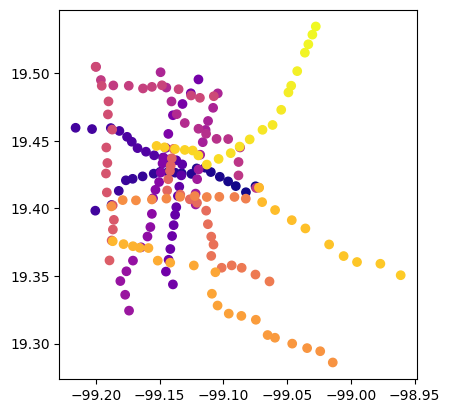

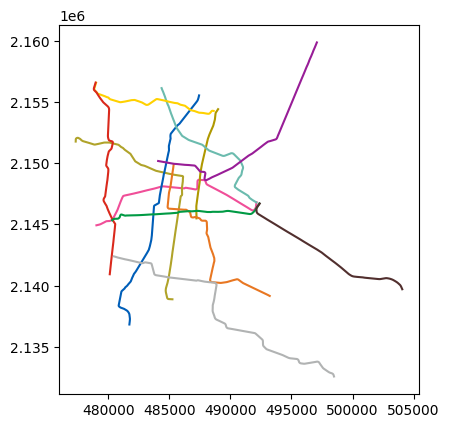

In [72]:
# Solo se muestra una vista previa de las capas

metro_estaciones.plot(cmap='plasma')

lineas_metro.plot(cmap=colores_metro)

In [73]:
#Se define un sistema de coordenadas acorde a la columna 'geometry' del DF, el 4326 se basa en grados

df1 = gpd.GeoDataFrame(df1, geometry='geometry', crs="EPSG:4326")

lineas_metro.crs

<Projected CRS: EPSG:32614>
Name: WGS 84 / UTM zone 14N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 102°W and 96°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Manitoba; Nunavut; Saskatchewan. Mexico. United States (USA).
- bounds: (-102.0, 0.0, -96.0, 84.0)
Coordinate Operation:
- name: UTM zone 14N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [74]:
#Para usar los métodos de visualización en geopandas se debe cambiar el sistema de coordenadas a uno que use metros (3857)

df1_mapa = df1.to_crs(epsg=3857)
lineas_metro_mapa = lineas_metro.to_crs(epsg=3857)


In [75]:
#Se comprueban los cambios en las coordenadas de las capas finales

print(df1_mapa.crs)
print(lineas_metro_mapa.crs)

EPSG:3857
EPSG:3857


In [76]:
#Se definen los colores en una nueva columna
colores_dict = {
    '1': '#F04E98', '2': '#005EB8',
    '3': '#AF9800', '4': '#6BBBAE',
    '5':'#FFD100','6':'#DA291C',
    '7':'#E87722','8':'#009A44',
    '9': '#512F2E', 'B': '#B1B3B3',
    'A':'#981D97','12':'#B0A32A'
}

lineas_metro_mapa['color'] = lineas_metro_mapa['LINEA'].map(colores_dict)

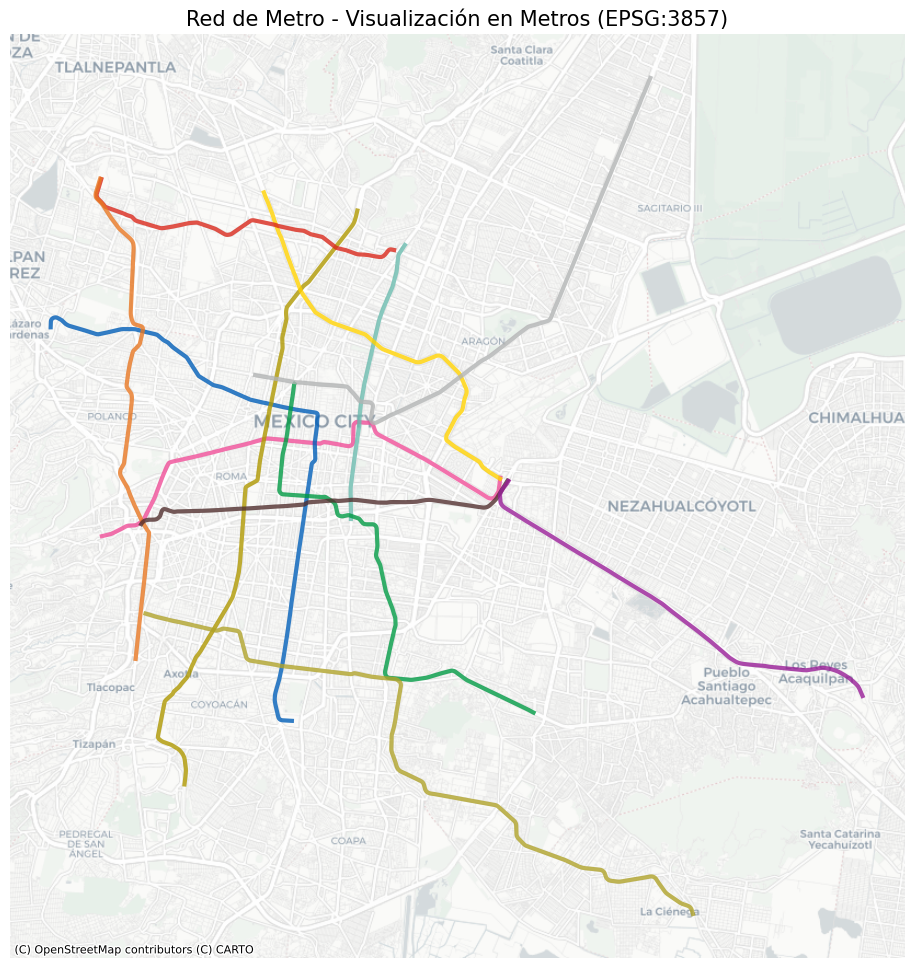

In [77]:
# Se genera una muestra base del mapa del metro para comprobar si no hay errores en los datos
fig, ax = plt.subplots(figsize=(12, 12))

lineas_metro_mapa.plot(ax=ax, color=lineas_metro_mapa['color'], linewidth=3, alpha=0.8)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.title("Red de Metro - Visualización en Metros (EPSG:3857)", fontsize=15)
plt.show()

In [78]:
# Se definen las propiedades del método explore para generar los mapas finales

df1_mapa.explore(column='linea', cmap=colores_metro, popup=True, marker_type="circle_marker", name='Estaciones Metro')

In [79]:
lineas_metro_mapa.explore(color=lineas_metro_mapa['color'], linewidth=3, alpha=0.8 ,name='Lineas Metro')

In [80]:
#Ambas capas se muestran con un control para cambiar la visibilidad

m = df1_mapa.explore(column='linea', cmap=colores_metro, popup=True, marker_type="circle_marker",radius=3,tiles='CartoDB positron', name='Estaciones Metro')

lineas_metro_mapa.explore(m=m, color=lineas_metro_mapa['color'], linewidth=3, alpha=0.8 ,tiles='CartoDB positron',name='Lineas Metro')

import folium
folium.LayerControl().add_to(m) #Control de capas

# Mostrar mapa
m

In [139]:
#m.save('mapa_metro.html')

#**Top 10 Estaciones con mayor afluencia**

##Preparación de los datos

In [92]:
#Con una copia del dataset que se transformó, se filtra por valores

top_estaciones = df1_grafica.copy()
top_estaciones.sort_values(by='afluencia',ascending=False,inplace=True)

top_estaciones.head(10)

,linea,estacion,afluencia,EST,CVE_EST,CVE_EOD17,TIPO,ALCALDIAS,AÑO,geometry
57,2,Cuatro Caminos,2683670,01,STC0201,05045,Terminal,Estado de México - Naucalpan de Juárez,1984,POINT Z (-99.21584 19.45959 0)
186,8,Constitución de 1917,2637286,19,STC0819,05140,Terminal,Iztapalapa,1994,POINT Z (-99.0638 19.34597 0)
97,3,Indios Verdes,2490967,01,STC0301,05076,Terminal,Gustavo A. Madero,1979,POINT Z (-99.11951 19.49534 0)
104,3,Universidad,1683445,21,STC0321,05084,Terminal,Coyoacán,1983,POINT Z (-99.17394 19.32435 0)
46,12,Tláhuac,1539034,01,STC1201,05037,Terminal,Tláhuac,2012,POINT Z (-99.0142 19.28602 0)
76,2,Tasqueña,1320000,24,STC0224,05060,Terminal,Coyoacán,1970,POINT Z (-99.13953 19.34376 0)
235,B,Buenavista,1316358,01,STCLB01,05176,Terminal,Cuauhtémoc,1999,POINT Z (-99.15235 19.44619 0)
220,9,Tacubaya,1291879,12,STC0912,05163,Terminal / Transbordo,Miguel Hidalgo,1988,POINT Z (-99.18776 19.40146 0)
218,9,Tacubaya,1291879,19,STC0119,05019,Transbordo,Miguel Hidalgo,1970,POINT Z (-99.18764 19.40251 0)
219,9,Tacubaya,1291879,10,STC0710,05133,Transbordo,Miguel Hidalgo,1985,POINT Z (-99.18675 19.40219 0)


In [101]:
#El top 10 de las estaciones con mayor flujo de personas, se eliminan los duplicados de estación

top_estaciones = top_estaciones.drop_duplicates(subset=['estacion'])

top10 = top_estaciones.head(10)

##Creación de la gráfica

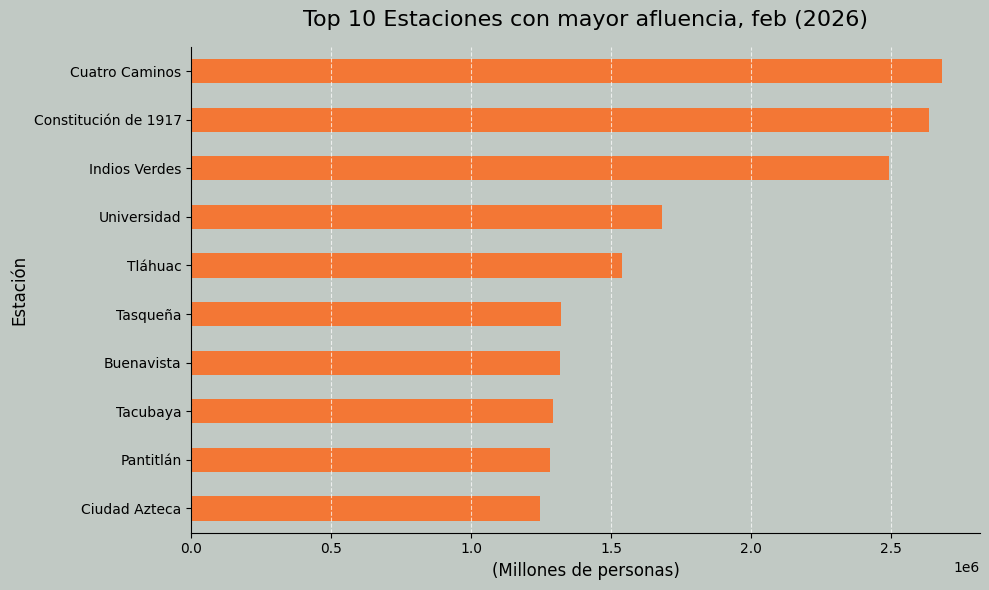

In [140]:
fig, ax = plt.subplots(figsize=(10, 6))

fig.set_facecolor('#c1c9c4')
ax.set_facecolor('#c1c9c4')

top10.plot(
    kind='barh',
    x='estacion',
    y='afluencia',
    color='#F37735',
    ax=ax,
    legend=False
)

ax.set_title('Top 10 Estaciones con mayor afluencia, feb (2026)', fontsize=16, pad=15)
ax.set_xlabel('(Millones de personas)', fontsize=12)
ax.set_ylabel('Estación', fontsize=12)
ax.invert_yaxis()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.7, color='white')

plt.tight_layout()

#plt.savefig('top10_estaciones.png', dpi=300, bbox_inches='tight')

plt.show()